In [14]:
# In this project, it's all about comparing the performance between randomforest and decisiontree

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
%matplotlib inline

wine = load_wine()

In [19]:
wine.data

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13))

In [20]:
wine.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [27]:
from sklearn.model_selection import train_test_split

Xtrain,Xtest,Ytrain,Ytest = train_test_split(wine.data,wine.target,test_size = 0.3)

In [28]:
clf = DecisionTreeClassifier(random_state = 0)
rfc = RandomForestClassifier(random_state= 0)
clf = clf.fit(Xtrain,Ytrain)
rfc = rfc.fit(Xtrain,Ytrain)
score_c = clf.score(Xtest,Ytest)
score_r = rfc.score(Xtest,Ytest)
print(f"Single Tree: {score_c}, Random Tree: {score_r}")

Single Tree: 0.9074074074074074, Random Tree: 0.9814814814814815


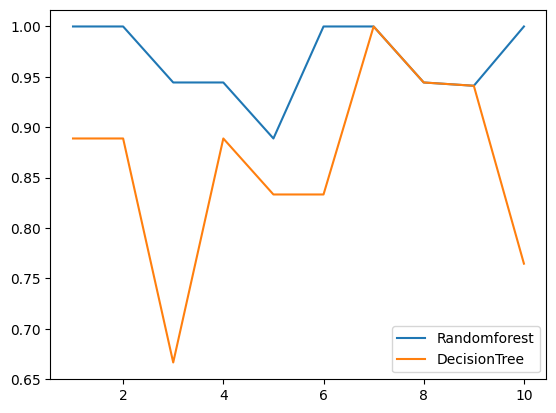

In [4]:
# Cross-validation
from sklearn.model_selection import cross_val_score
rfc = RandomForestClassifier(n_estimators=25)
rfc_s = cross_val_score(rfc,wine.data,wine.target,cv=10)

clf = DecisionTreeClassifier()
clf_s = cross_val_score(clf,wine.data,wine.target,cv=10)

plt.plot(range(1,11),rfc_s,label="Randomforest")
plt.plot(range(1,11),clf_s,label="DecisionTree")
plt.legend()
plt.show()
#Randomforest has a better performance compared to DecisionTree

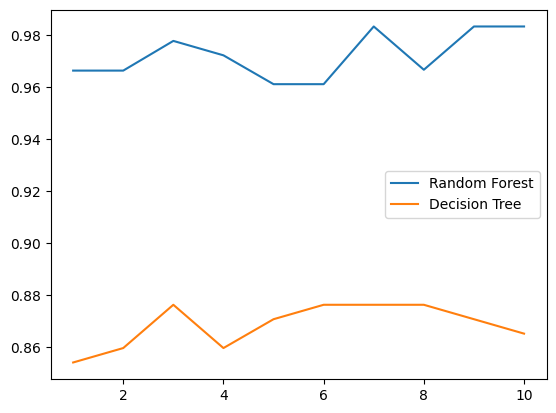

In [10]:
# I wanted to see how the trend vary if there's 100 times cross-validation
# Random achieves a better proformance if more testing are done
rfc_list = []
clf_list = []

for i in range(10):
    rfc = RandomForestClassifier(n_estimators=25)
    rfc_s = cross_val_score(rfc,wine.data,wine.target,cv=10).mean()
    rfc_list.append(rfc_s)

    clf = DecisionTreeClassifier()
    clf_s = cross_val_score(clf,wine.data,wine.target,cv=10).mean()
    clf_list.append(clf_s)
    
plt.plot(range(1,11),rfc_list,label="Random Forest")
plt.plot(range(1,11),clf_list,label="Decision Tree")
plt.legend()
plt.show()

0.9888888888888889 31


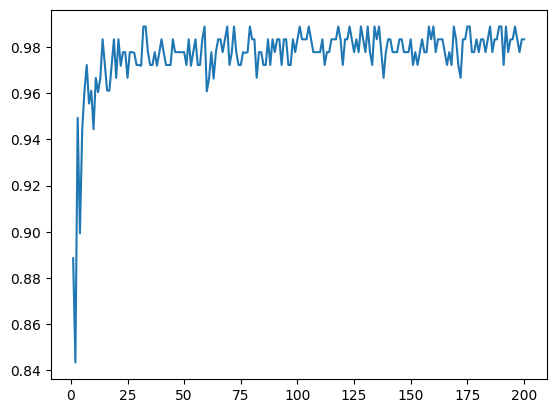

In [12]:
# Wanted to see at what number of n_estimators will the performance reaches the highest level.

trend = []
for i in range(200):
    rfc = RandomForestClassifier(n_estimators= i+1,n_jobs=-1)
    rfc_s = cross_val_score(rfc,wine.data,wine.target,cv=10).mean()
    trend.append(rfc_s)

print(max(trend),trend.index(max(trend)))
plt.plot(range(1,201),trend)
plt.show()

In [13]:
# The probability that random forest has the wrong result for the wine sample
import numpy as np
from scipy.special import comb

np.array([comb(25, i) * (0.2 ** i) * (0.8 ** (25 - i)) for i in range(13, 26)]).sum()

np.float64(0.00036904803455582827)